<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
     border-radius: 16px; padding: 40px 48px 36px; margin-bottom: 8px; color: white; font-family: 'Segoe UI', sans-serif;">

  <div style="font-size: 11px; letter-spacing: 3px; text-transform: uppercase;
       color: #e94560; font-weight: 600; margin-bottom: 12px;">
    Data Analysis Portfolio
  </div>

  <h1 style="margin: 0 0 8px; font-size: 28px; font-weight: 700; line-height: 1.3; color: #ffffff;">
    E-Commerce Performance Analytics
  </h1>

  <p style="margin: 0 0 24px; font-size: 14px; color: #a8b2c1; line-height: 1.6;">
    巴西電商平台 Olist｜客群價值分析 · 配送品質 · 產品策略 · KMeans 分群
  </p>

  <div style="display: flex; gap: 12px; flex-wrap: wrap; margin-bottom: 28px;">
    <span style="background: rgba(233,69,96,0.15); border: 1px solid rgba(233,69,96,0.4);
         border-radius: 20px; padding: 4px 14px; font-size: 12px; color: #e94560;">RFM Segmentation</span>
    <span style="background: rgba(82,130,255,0.15); border: 1px solid rgba(82,130,255,0.4);
         border-radius: 20px; padding: 4px 14px; font-size: 12px; color: #5282ff;">Delivery Analysis</span>
    <span style="background: rgba(0,200,150,0.15); border: 1px solid rgba(0,200,150,0.4);
         border-radius: 20px; padding: 4px 14px; font-size: 12px; color: #00c896;">Pareto / ABC</span>
    <span style="background: rgba(255,180,0,0.15); border: 1px solid rgba(255,180,0,0.4);
         border-radius: 20px; padding: 4px 14px; font-size: 12px; color: #ffb400;">KMeans + PCA</span>
    <span style="background: rgba(180,100,255,0.15); border: 1px solid rgba(180,100,255,0.4);
         border-radius: 20px; padding: 4px 14px; font-size: 12px; color: #b464ff;">Statistical Tests</span>
  </div>

  <div style="border-top: 1px solid rgba(255,255,255,0.1); padding-top: 20px;">
    <p style="margin: 0 0 12px; font-size: 12px; color: #7a8494; letter-spacing: 1px; text-transform: uppercase;">
      Research Questions
    </p>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px;">
      <div style="background: rgba(255,255,255,0.05); border-radius: 8px; padding: 12px 16px; font-size: 13px; color: #c8d0dc; line-height: 1.5;">
        <span style="color: #e94560; font-weight: 700; margin-right: 8px;">Q1</span>哪些客群貢獻最高營收？如何識別高價值與流失風險客戶？
      </div>
      <div style="background: rgba(255,255,255,0.05); border-radius: 8px; padding: 12px 16px; font-size: 13px; color: #c8d0dc; line-height: 1.5;">
        <span style="color: #5282ff; font-weight: 700; margin-right: 8px;">Q2</span>配送延遲如何影響顧客滿意度？延遲訂單有哪些可辨識特徵？
      </div>
      <div style="background: rgba(255,255,255,0.05); border-radius: 8px; padding: 12px 16px; font-size: 13px; color: #c8d0dc; line-height: 1.5;">
        <span style="color: #00c896; font-weight: 700; margin-right: 8px;">Q3</span>哪些品類驅動主要營收（80/20）？價格與滿意度的關係為何？
      </div>
      <div style="background: rgba(255,255,255,0.05); border-radius: 8px; padding: 12px 16px; font-size: 13px; color: #c8d0dc; line-height: 1.5;">
        <span style="color: #ffb400; font-weight: 700; margin-right: 8px;">Q4</span>能否透過 KMeans 找出具有明確行為差異的客群側寫？
      </div>
    </div>
  </div>

  <div style="margin-top: 20px; display: flex; gap: 24px; font-size: 12px; color: #7a8494;">
    <span>📦 Dataset：Olist Brazilian E-Commerce</span>
    <span>🗓 2016 – 2018</span>
    <span>📊 ~100K orders · 9 CSV files</span>
  </div>
</div>

## 使用套件

| 套件 | 用途 |
|------|------|
| `warnings` | 抑制執行期間的非關鍵警告訊息 |
| `pandas` | 資料讀取、清理、合併與聚合，核心資料結構 DataFrame |
| `numpy` | 數值計算、log 轉換、陣列操作 |
| `pathlib` | 跨平台檔案路徑處理 |
| `matplotlib` | 基礎繪圖引擎，雙軸折線 / 長條圖、直方圖 |
| `seaborn` | 基於 matplotlib 的統計視覺化，熱力圖、箱型圖、散佈圖 |
| `scipy.stats` | 統計檢定：Shapiro-Wilk、Mann-Whitney U、Kruskal-Wallis、Chi² |
| `sklearn.preprocessing` | StandardScaler：特徵標準化（mean=0, std=1） |
| `sklearn.cluster` | KMeans：非監督式分群演算法 |
| `sklearn.decomposition` | PCA：主成分分析，降維至二維以供視覺化 |
| `sklearn.metrics` | silhouette_score：評估分群品質（-1 ～ 1，越高越好） |

In [52]:
# importing libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── 中文字型設定（仿 R showtext 做法）───────────────────────────
# Step 1：取得字型檔案路徑（類似 font_add_google）
_candidates = ['PingFang HK', 'PingFang SC', 'Heiti TC', 'STHeiti',
               'Hiragino Sans GB', 'Arial Unicode MS']
_available  = {f.name for f in fm.fontManager.ttflist}
_match      = next((f for f in _candidates if f in _available), None)

if _match:
    _font_path = fm.findfont(fm.FontProperties(family=_match))
    # Step 2：明確載入字型（類似 font_add_google 的 addfont）
    fm.fontManager.addfont(_font_path)
    _font_name = fm.FontProperties(fname=_font_path).get_name()
    # Step 3：設定 seaborn + matplotlib，rc 參數防止 set_theme 覆蓋
    sns.set_theme(style='whitegrid', rc={
        'font.family':        'sans-serif',
        'font.sans-serif':    [_font_name, 'DejaVu Sans'],
        'axes.unicode_minus': False,
    })
    print(f"中文字型已載入：{_font_name}  ({_font_path.split('/')[-1]})")
else:
    sns.set_theme(style='whitegrid')
    print("⚠️  找不到中文字型")


中文字型已載入：PingFang HK  (PingFang.ttc)


資料介紹

In [53]:
# loading data
customers = pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/olist_customers_dataset.csv') 
orders= pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/olist_orders_dataset.csv')
orders_items= pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/olist_order_items_dataset.csv')
orders_payments= pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/olist_order_payments_dataset.csv')
orders_reviews= pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/olist_order_reviews_dataset.csv')
geolocation= pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/olist_geolocation_dataset.csv')
sellers= pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/olist_sellers_dataset.csv')
product_category_name= pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/product_category_name_translation.csv')
products= pd.read_csv('/Users/aditi/Documents/Data_Analysis_Portfolio/MitsuiPrediction_Project/Data/raw_data/olist/olist_products_dataset.csv')

In [54]:
# 建立 datasets 字典
datasets = {
    "customers": customers,
    "orders": orders,
    "orders_items": orders_items,
    "orders_payments": orders_payments,
    "orders_reviews": orders_reviews,
    "geolocation": geolocation,
    "sellers": sellers,
    "product_category_name": product_category_name,
    "products": products,
}

# 一次檢查所有資料集
for name, d in datasets.items():
    print(f"\n{'='*40}")
    print(f"📄 {name}")
    print(f"Shape : {d.shape}")
    print(f"Dtypes:\n{d.dtypes}")
    print(f"Nulls :\n{d.isnull().sum()[d.isnull().sum()>0]}")
    print(f"Dupes : {d.duplicated().sum()}")




📄 customers
Shape : (99441, 5)
Dtypes:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object
Nulls :
Series([], dtype: int64)
Dupes : 0

📄 orders
Shape : (99441, 8)
Dtypes:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
Nulls :
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Dupes : 0

📄 orders_items
Shape : (112650, 7)
Dtypes:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_val

## 資料清理與特徵工程

In [55]:
# ── 1. 聚合 orders_items（含產品、品類翻譯）──────────────────────
items_ext = (
    orders_items
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(product_category_name, on='product_category_name', how='left')
)
items_agg = items_ext.groupby('order_id', as_index=False).agg(
    item_count       = ('order_item_id',                 'count'),
    total_price      = ('price',                         'sum'),
    total_freight    = ('freight_value',                 'sum'),
    product_category = ('product_category_name_english', lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else np.nan),
    seller_id        = ('seller_id',                     'first'),
)

# ── 2. 聚合 payments ─────────────────────────────────────────────
payments_agg = orders_payments.groupby('order_id', as_index=False).agg(
    payment_value        = ('payment_value',        'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type         = ('payment_type',          lambda x: x.mode().iloc[0]),
)

# ── 3. 聚合 reviews（同訂單可能多筆）────────────────────────────────
reviews_agg = orders_reviews.groupby('order_id', as_index=False).agg(
    review_score = ('review_score', 'mean'),
)

# ── 4. 合併所有表到 orders ────────────────────────────────────────
df = (
    orders
    .merge(customers,    on='customer_id', how='left')
    .merge(items_agg,    on='order_id',    how='left')
    .merge(sellers,      on='seller_id',   how='left')
    .merge(payments_agg, on='order_id',    how='left')
    .merge(reviews_agg,  on='order_id',    how='left')
)

print(f"合併後 shape: {df.shape}")
df.head(2)

合併後 shape: (99441, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,total_freight,product_category,seller_id,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,9350.0,maua,SP,38.71,1.0,voucher,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumery,289cdb325fb7e7f891c38608bf9e0962,31570.0,belo horizonte,SP,141.46,1.0,boleto,4.0


In [56]:
# ── 5. 只保留 delivered 訂單 ─────────────────────────────────────
df = df[df['order_status'] == 'delivered'].copy()
print(f"delivered 訂單數: {len(df)}")

# ── 6. 轉換日期欄位 ───────────────────────────────────────────────
dt_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in dt_cols:
    df[col] = pd.to_datetime(df[col])

# ── 7. 處理遺失值 ─────────────────────────────────────────────────
# 必要欄位缺失 → 刪除該列
df.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'], inplace=True)

# 數值欄位 → 中位數填補
for col in ['total_price', 'total_freight', 'payment_value', 'review_score']:
    df[col] = df[col].fillna(df[col].median())

# 類別欄位 → 'unknown' 填補
for col in ['product_category', 'payment_type']:
    df[col] = df[col].fillna('unknown')

print(f"清理後 shape: {df.shape}")
remaining_nulls = df.isnull().sum()
print(f"剩餘缺失值:\n{remaining_nulls[remaining_nulls > 0]}")

# ── 8. 衍生特徵 ───────────────────────────────────────────────────
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days']    = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late']       = (df['delay_days'] > 0).astype(int)

print(f"\n📦 delivery_days — 平均: {df['delivery_days'].mean():.1f} 天")
print(f"⏰ is_late 比率  — {df['is_late'].mean()*100:.1f}%")
df[['delivery_days', 'delay_days', 'is_late']].describe()

delivered 訂單數: 96478
清理後 shape: (96470, 24)
剩餘缺失值:
order_approved_at               14
order_delivered_carrier_date     1
payment_installments             1
dtype: int64

📦 delivery_days — 平均: 12.1 天
⏰ is_late 比率  — 6.8%


,delivery_days,delay_days,is_late
count,96470.000000,96470.000000,96470.000000
mean,12.093604,-11.875889,0.067731
std,9.551380,10.182105,0.251285
min,0.000000,-147.000000,0.000000
25%,6.000000,-17.000000,0.000000
50%,10.000000,-12.000000,0.000000
75%,15.000000,-7.000000,0.000000
max,209.000000,188.000000,1.000000


## 營運脈搏 (Revenue Pulse)

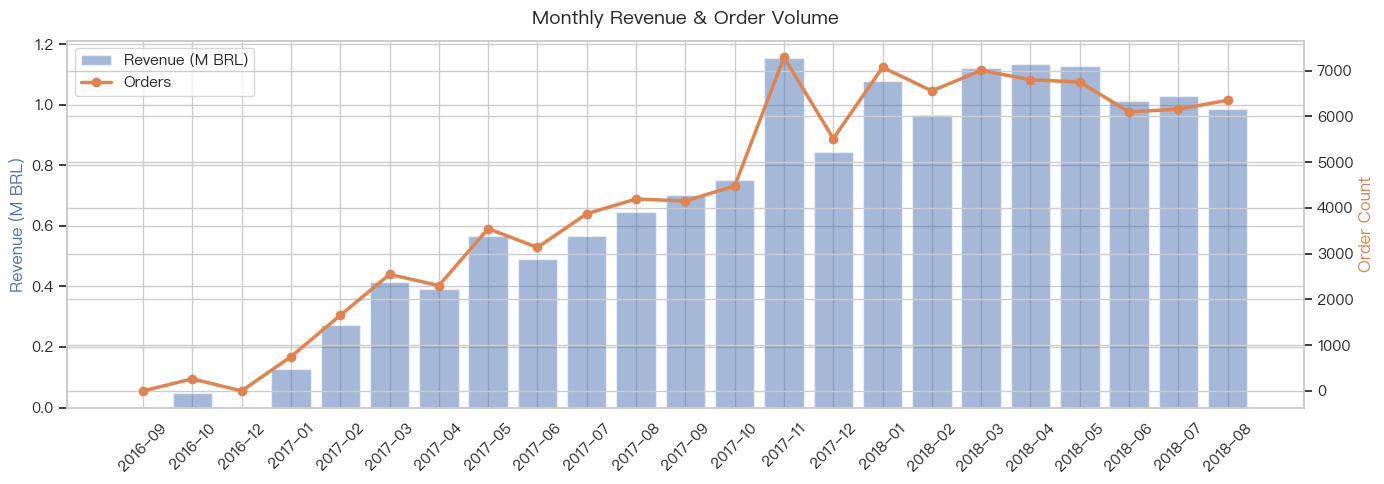

In [57]:
# ── 月營收 + 訂單量趨勢 ──────────────────────────────────────────
monthly = (
    df.assign(ym=df['order_purchase_timestamp'].dt.to_period('M'))
    .groupby('ym')
    .agg(revenue=('payment_value', 'sum'), orders=('order_id', 'count'))
    .reset_index()
)
monthly['ym'] = monthly['ym'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['ym'], monthly['revenue'] / 1e6,
        color='#4C72B0', alpha=0.5, label='Revenue (M BRL)')
ax2.plot(monthly['ym'], monthly['orders'],
         color='#DD8452', marker='o', linewidth=2.5, label='Orders')

ax1.set_ylabel('Revenue (M BRL)', color='#4C72B0')
ax2.set_ylabel('Order Count',     color='#DD8452')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('Monthly Revenue & Order Volume', fontsize=14, pad=12)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

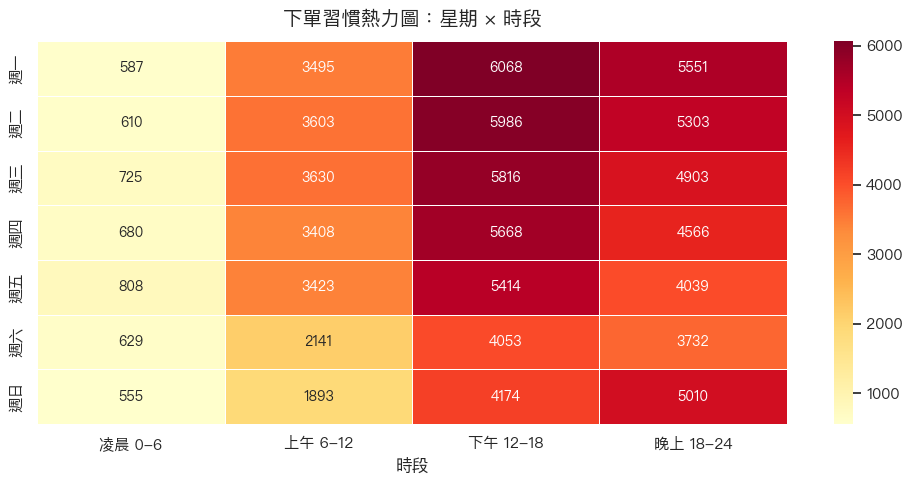

In [58]:
# ── 週 × 時段熱力圖（下單習慣）──────────────────────────────────
df['dow']  = df['order_purchase_timestamp'].dt.dayofweek
df['hour'] = df['order_purchase_timestamp'].dt.hour

bins   = [0, 6, 12, 18, 24]
labels = ["凌晨 0-6", "上午 6-12", "下午 12-18", "晚上 18-24"]
df['time_slot'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False)

day_labels = ["週一", "週二", "週三", "週四", "週五", "週六", "週日"]
pivot = (
    df.groupby(['dow', 'time_slot'], observed=True)
    .size()
    .unstack('time_slot')
)
pivot.index = day_labels

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 10}, ax=ax)
ax.set_title("下單習慣熱力圖：星期 × 時段", fontsize=14, pad=12)
ax.set_xlabel("時段")
ax.set_ylabel('')
plt.tight_layout()
plt.show()

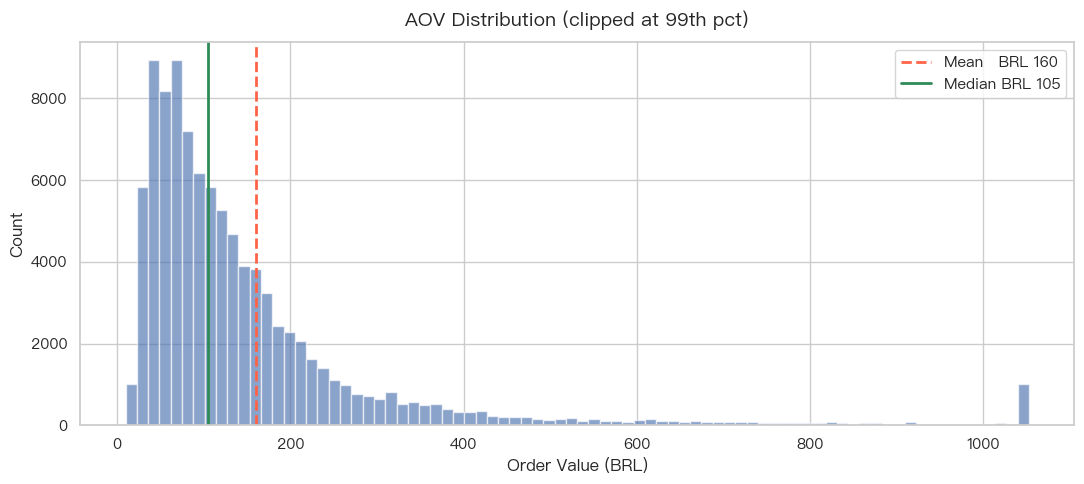

In [59]:
# ── AOV 分佈直方圖 + Mean / Median 標線 ─────────────────────────
aov      = df['payment_value'].clip(upper=df['payment_value'].quantile(0.99))
mean_v   = df['payment_value'].mean()
median_v = df['payment_value'].median()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(aov, bins=80, color='#4C72B0', alpha=0.65, edgecolor='white')
ax.axvline(mean_v,   color='tomato',   linestyle='--', linewidth=2,
           label=f'Mean   BRL {mean_v:.0f}')
ax.axvline(median_v, color='seagreen', linestyle='-',  linewidth=2,
           label=f'Median BRL {median_v:.0f}')
ax.set_xlabel('Order Value (BRL)')
ax.set_ylabel('Count')
ax.set_title('AOV Distribution (clipped at 99th pct)', fontsize=14, pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 客群 RFM 分析

In [60]:
# ── RFM 計算 ────────────────────────────────────────────────────
snapshot = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby('customer_unique_id')
    .agg(
        recency   = ('order_purchase_timestamp', lambda x: (snapshot - x.max()).days),
        frequency = ('order_id',                 'count'),
        monetary  = ('payment_value',            'sum'),
    )
    .reset_index()
)

# 1-5 分位分數（R 反向：越近 = 分越高）
rfm['R'] = pd.qcut(rfm['recency'],                        5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),  5, labels=[1,2,3,4,5]).astype(int)

# 規則式貼標
def rfm_label(r, f):
    if r >= 4 and f >= 4: return 'Champions'
    if r >= 3 and f >= 3: return 'Loyal'
    if r >= 4 and f <= 2: return 'New Customers'
    if r >= 3 and f <= 2: return 'Potential Loyalists'
    if r <= 2 and f >= 3: return 'At Risk'
    return 'Lost'

rfm['segment'] = rfm.apply(lambda row: rfm_label(row['R'], row['F']), axis=1)
print(rfm['segment'].value_counts().to_string())
rfm.head()

segment
At Risk                22228
Loyal                  18823
Lost                   14986
New Customers          14980
Champions              14959
Potential Loyalists     7374


,customer_unique_id,recency,frequency,monetary,R,F,M,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,New Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,New Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,Lost
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,Lost


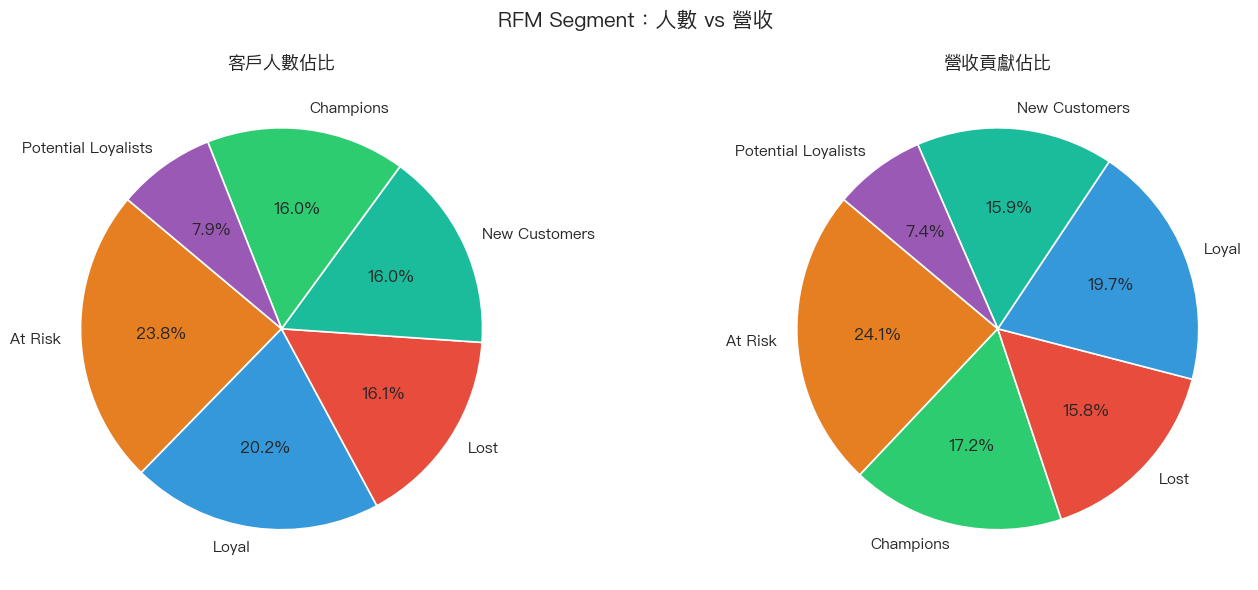

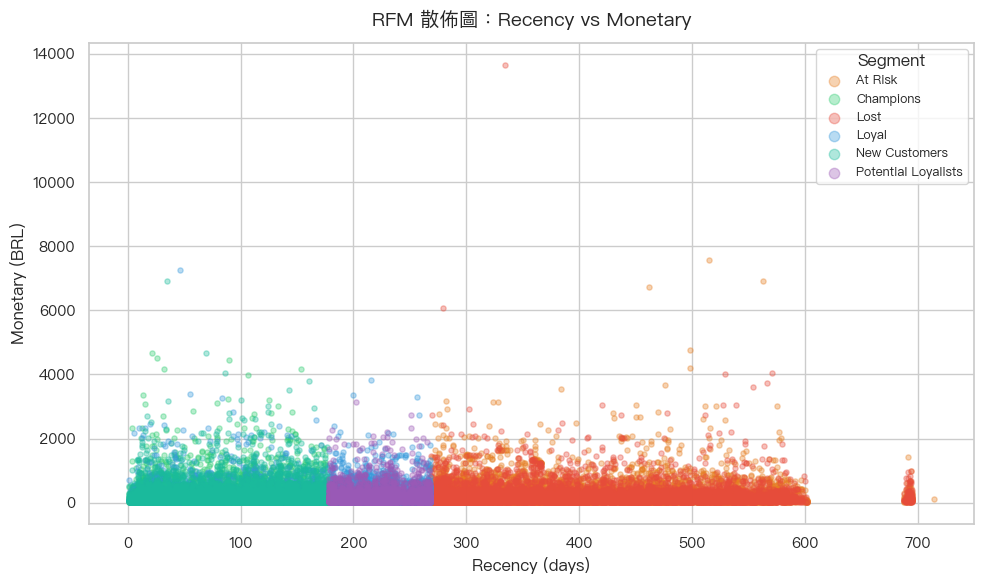

In [61]:
SEG_COLORS = {
    'Champions':           '#2ecc71',
    'Loyal':               '#3498db',
    'Potential Loyalists': '#9b59b6',
    'New Customers':       '#1abc9c',
    'At Risk':             '#e67e22',
    'Lost':                '#e74c3c',
}

seg_count   = rfm['segment'].value_counts()
seg_revenue = rfm.groupby('segment')['monetary'].sum()

# ── 圓餅圖：人數 vs 營收 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title in zip(axes,
                            [seg_count, seg_revenue],
                            ["客戶人數佔比", "營收貢獻佔比"]):
    colors = [SEG_COLORS.get(s, '#95a5a6') for s in data.index]
    ax.pie(data, labels=data.index, autopct='%1.1f%%', colors=colors,
           startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
    ax.set_title(title, fontsize=13)
plt.suptitle("RFM Segment：人數 vs 營收", fontsize=15)
plt.tight_layout()
plt.show()

# ── RFM 散佈圖（Recency vs Monetary，顏色 = 客群）───────────────
fig, ax = plt.subplots(figsize=(10, 6))
for seg, grp in rfm.groupby('segment'):
    ax.scatter(grp['recency'], grp['monetary'],
               label=seg, alpha=0.35, s=14,
               color=SEG_COLORS.get(seg, '#95a5a6'))
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Monetary (BRL)')
ax.set_title("RFM 散佈圖：Recency vs Monetary", fontsize=14, pad=12)
ax.legend(markerscale=2, fontsize=9, title='Segment')
plt.tight_layout()
plt.show()

## 產品戰略

     品類數  營收_M
ABC           
A     12  10.6
B     13   3.2
C     47   1.6


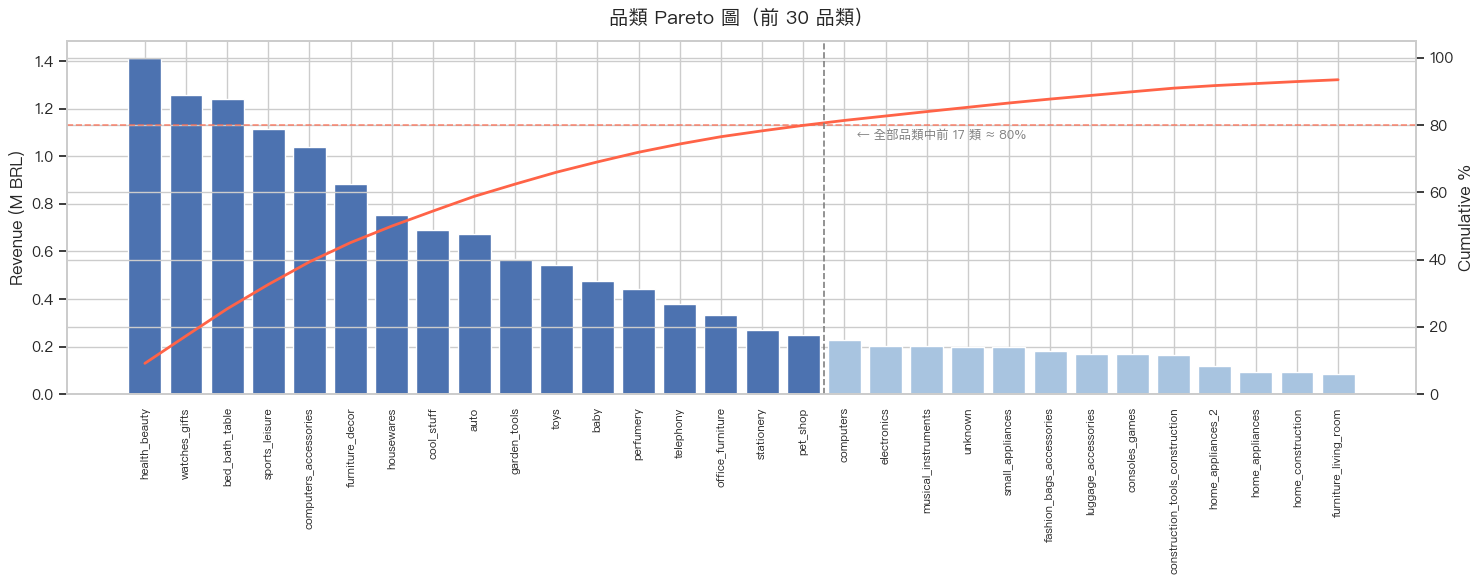

In [62]:
# ── 品類 Pareto + ABC 分類 ───────────────────────────────────────
cat_rev_all = (
    df.groupby('product_category')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
total_rev = cat_rev_all['payment_value'].sum()
cat_rev_all['cum_pct'] = cat_rev_all['payment_value'].cumsum() / total_rev * 100

def abc_label(cum):
    if cum <= 70: return 'A'
    if cum <= 90: return 'B'
    return 'C'

cat_rev_all['ABC'] = cat_rev_all['cum_pct'].apply(abc_label)
print(cat_rev_all.groupby('ABC').agg(
    品類數=('product_category', 'count'),
    營收_M=('payment_value',    lambda x: round(x.sum()/1e6, 1))
).to_string())

# 只取前 30 品類繪圖
cat_top = cat_rev_all.head(30).copy()
threshold_idx = int((cat_top['cum_pct'] <= 80).sum())
threshold_n   = int((cat_rev_all['cum_pct'] <= 80).sum())

fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()

bar_colors = ['#4C72B0' if i < threshold_idx else '#a8c4e0'
              for i in range(len(cat_top))]
ax1.bar(range(len(cat_top)), cat_top['payment_value'] / 1e6, color=bar_colors)
ax2.plot(range(len(cat_top)), cat_top['cum_pct'], color='tomato', linewidth=2)
ax2.axhline(80, color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.axvline(threshold_idx - 0.5, color='gray', linestyle='--', linewidth=1.2)
ax2.text(threshold_idx + 0.3, 76,
         f"← 全部品類中前 {threshold_n} 類 ≈ 80%", fontsize=9, color='gray')

ax1.set_xticks(range(len(cat_top)))
ax1.set_xticklabels(cat_top['product_category'], rotation=90, fontsize=8)
ax1.set_ylabel('Revenue (M BRL)')
ax2.set_ylabel('Cumulative %')
ax2.set_ylim(0, 105)
ax1.set_title("品類 Pareto 圖（前 30 品類）", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

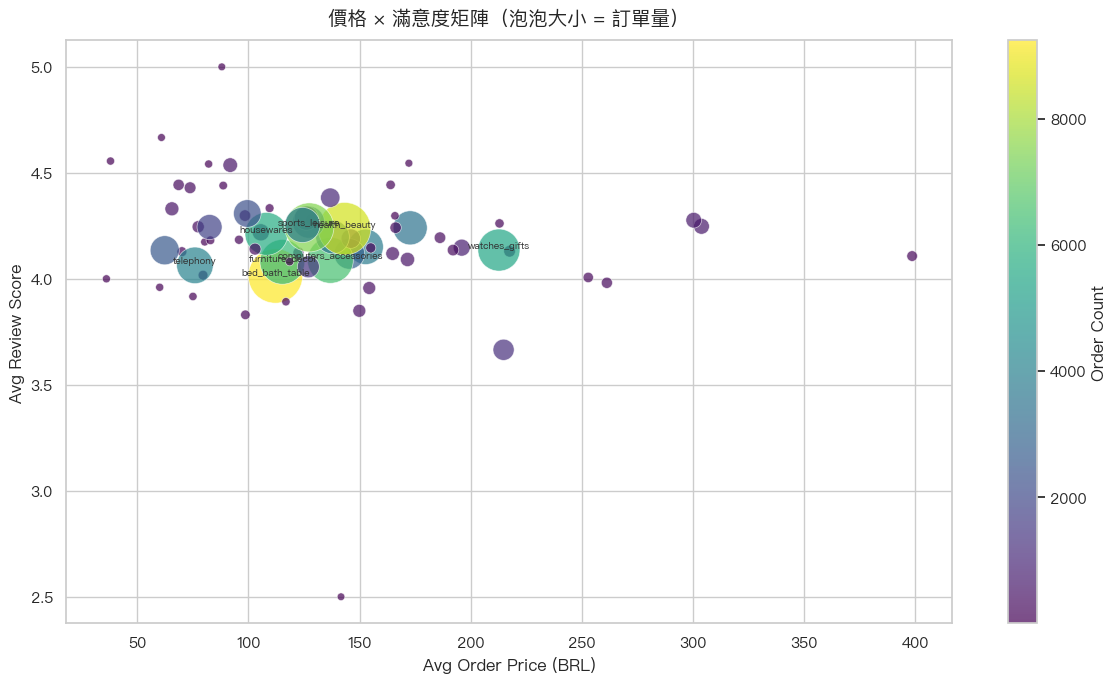

In [63]:
# ── 價格 × 滿意度矩陣（泡泡大小 = 訂單量）──────────────────────
bubble = (
    df.groupby('product_category')
    .agg(
        avg_price   = ('total_price',  'mean'),
        avg_review  = ('review_score', 'mean'),
        order_count = ('order_id',     'count'),
    )
    .reset_index()
    .dropna()
)
# 截去 avg_price 極端值避免拉扯座標
price_cap = bubble['avg_price'].quantile(0.97)
bubble_plot = bubble[bubble['avg_price'] <= price_cap].copy()

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(
    bubble_plot['avg_price'], bubble_plot['avg_review'],
    s=bubble_plot['order_count'] / bubble_plot['order_count'].max() * 1500 + 30,
    c=bubble_plot['order_count'], cmap='viridis', alpha=0.7,
    edgecolors='white', linewidth=0.5
)
plt.colorbar(sc, ax=ax, label='Order Count')

for _, row in bubble_plot.nlargest(8, 'order_count').iterrows():
    ax.annotate(row['product_category'],
                xy=(row['avg_price'], row['avg_review']),
                fontsize=7, ha='center', va='bottom', color='#333')

ax.set_xlabel('Avg Order Price (BRL)')
ax.set_ylabel('Avg Review Score')
ax.set_title("價格 × 滿意度矩陣（泡泡大小 = 訂單量）", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## 服務品質 / 配送

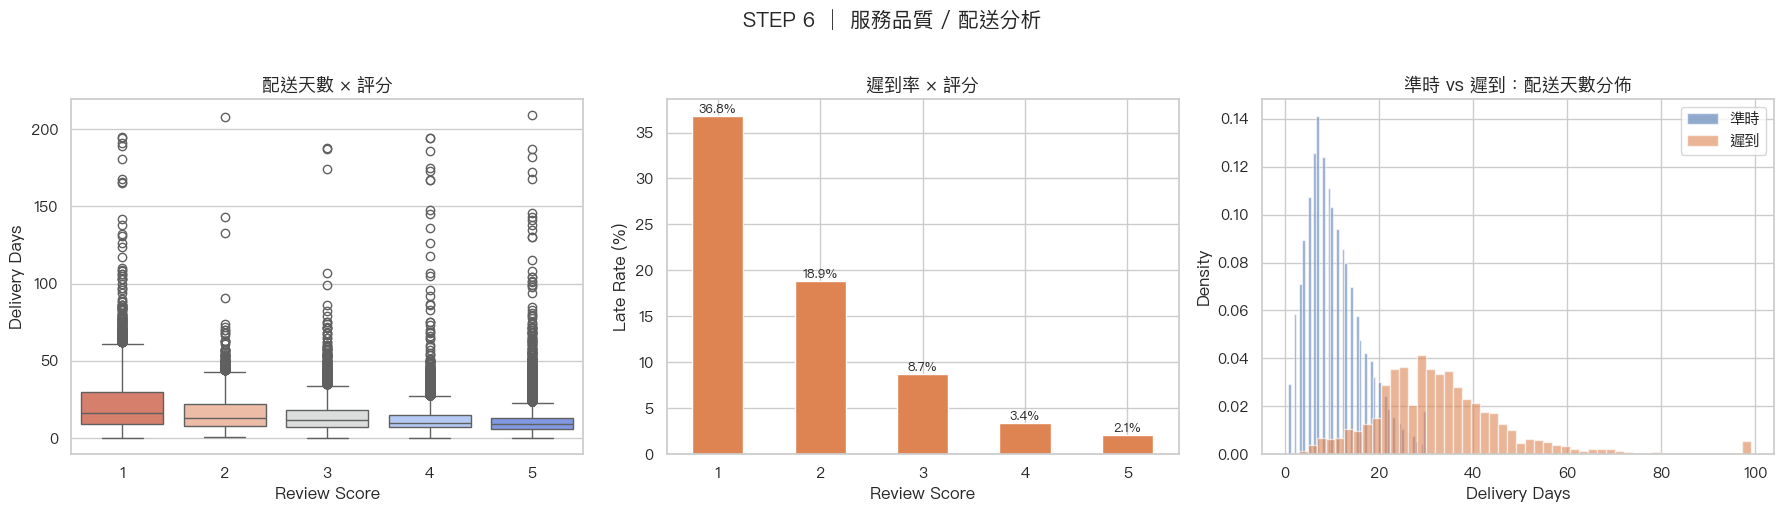

In [64]:
df['review_score_int'] = df['review_score'].round().astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 配送天數 × 評分箱型圖（斷崖視覺化）──────────────────────────
sns.boxplot(data=df, x='review_score_int', y='delivery_days',
            palette='coolwarm_r', ax=axes[0])
axes[0].set_title("配送天數 × 評分", fontsize=13)
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Delivery Days')

# ── 遲到率 × 評分長條圖 ───────────────────────────────────────────
late_rate = df.groupby('review_score_int')['is_late'].mean() * 100
late_rate.plot(kind='bar', ax=axes[1], color='#DD8452', edgecolor='white', rot=0)
axes[1].set_title("遲到率 × 評分", fontsize=13)
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Late Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# ── 準時 vs 遲到 配送天數分佈 ────────────────────────────────────
for label, grp in df.groupby('is_late'):
    clipped = grp['delivery_days'].clip(upper=grp['delivery_days'].quantile(0.99))
    axes[2].hist(clipped, bins=50, alpha=0.6, density=True,
                 label="遲到" if label else "準時")
axes[2].set_title("準時 vs 遲到：配送天數分佈", fontsize=13)
axes[2].set_xlabel('Delivery Days')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle("STEP 6 │ 服務品質 / 配送分析", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 統計檢定

            檢定               問題   p-value    結論（α=0.05）
  Shapiro-Wilk        AOV 是否常態？  2.95e-80         非常態 ✗
Mann-Whitney U 準時 vs 遲到 AOV 差異？  1.29e-19        顯著差異 ✓
Kruskal-Wallis        各州評分是否不同？ 3.05e-103        顯著差異 ✓
          Chi²     遲到 ↔ 評分有無關聯？  0.00e+00 有關聯 ✓ (dof=4)


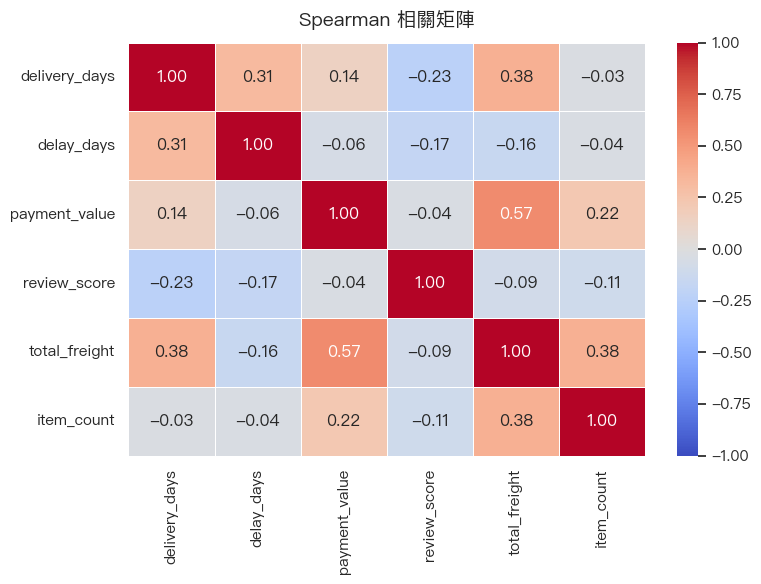

In [65]:

results = []

# 1. Shapiro-Wilk：AOV 常態性（最多 5000 樣本）
sample = df['payment_value'].dropna().sample(min(5000, len(df)), random_state=42)
_, p = stats.shapiro(sample)
results.append(('Shapiro-Wilk',    "AOV 是否常態？",           f'{p:.2e}',
                 "非常態 ✗" if p < 0.05 else "常態 ✓"))

# 2. Mann-Whitney U：準時 vs 遲到 AOV
on_time = df[df['is_late'] == 0]['payment_value'].dropna()
late    = df[df['is_late'] == 1]['payment_value'].dropna()
_, p = stats.mannwhitneyu(on_time, late, alternative='two-sided')
results.append(('Mann-Whitney U',  "準時 vs 遲到 AOV 差異？",  f'{p:.2e}',
                 "顯著差異 ✓" if p < 0.05 else "無差異 ✗"))

# 3. Kruskal-Wallis：各州評分差異
groups = [g['review_score'].dropna().values
          for _, g in df.groupby('customer_state') if len(g) >= 30]
_, p = stats.kruskal(*groups)
results.append(('Kruskal-Wallis',  "各州評分是否不同？",        f'{p:.2e}',
                 "顯著差異 ✓" if p < 0.05 else "無差異 ✗"))

# 4. Chi²：遲到 vs 評分關聯
ct = pd.crosstab(df['is_late'], df['review_score_int'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
results.append(('Chi²',            "遲到 ↔ 評分有無關聯？",    f'{p:.2e}',
                 f"有關聯 ✓ (dof={dof})" if p < 0.05 else "無關聯 ✗"))

res_df = pd.DataFrame(results, columns=["檢定", "問題", 'p-value', "結論（α=0.05）"])
print(res_df.to_string(index=False))

# ── Spearman 相關矩陣 ─────────────────────────────────────────────
cols = ['delivery_days', 'delay_days', 'payment_value',
        'review_score', 'total_freight', 'item_count']
corr = df[cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman 相關矩陣", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## KMeans 分群

最佳 k = 2  │  Silhouette = 0.7104


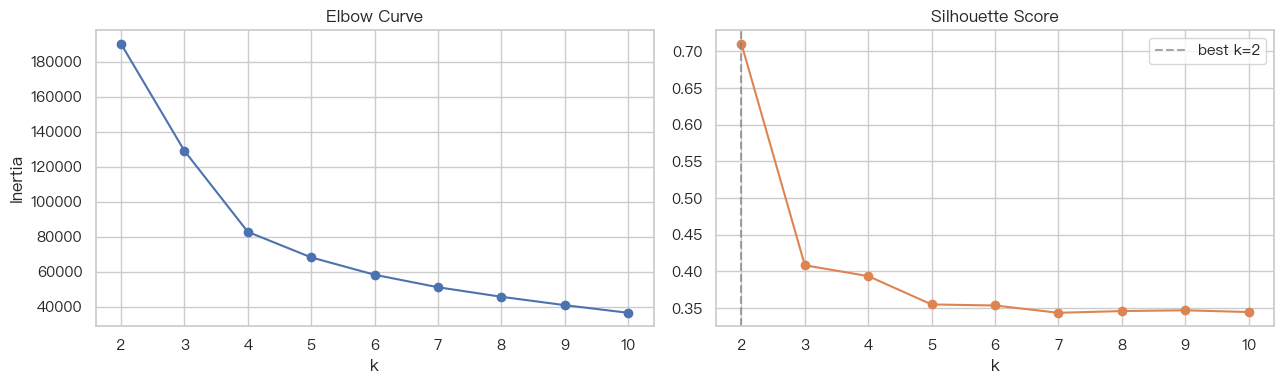

In [66]:

# ── Log 轉換 + StandardScaler ────────────────────────────────────
X_raw = np.log1p(rfm[['recency', 'frequency', 'monetary']])
X     = StandardScaler().fit_transform(X_raw)

# ── Elbow + Silhouette 自動選最佳 k ─────────────────────────────
# sample_size=5000 避免全量 pairwise distance 計算超時
K_range    = range(2, 11)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(
        silhouette_score(X, km.labels_, sample_size=5000, random_state=42)
    )

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"最佳 k = {best_k}  │  Silhouette = {max(sil_scores):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Curve'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(K_range, sil_scores, marker='o', color='#DD8452')
axes[1].axvline(best_k, linestyle='--', color='gray', alpha=0.7, label=f'best k={best_k}')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].legend()
plt.tight_layout()
plt.show()

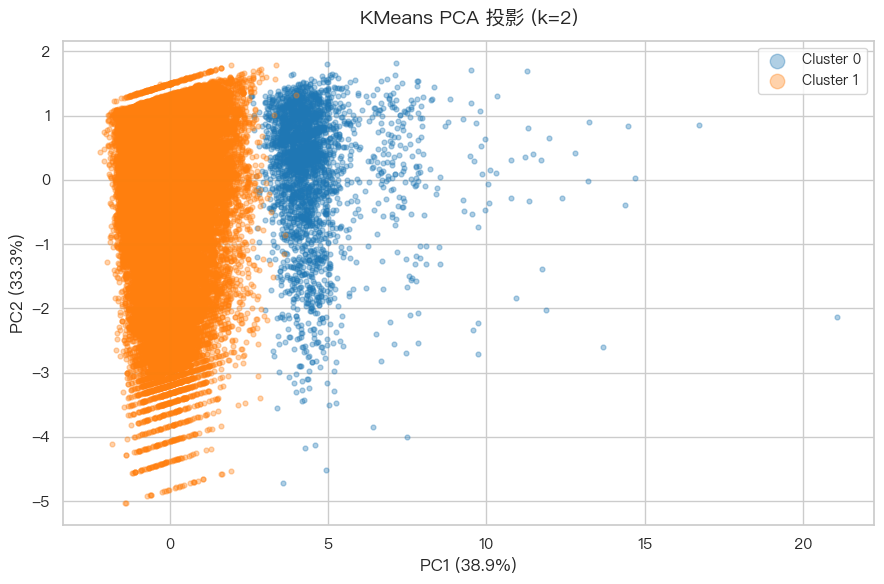

In [67]:
# ── 最佳 k 訓練 + PCA 二維投影 ──────────────────────────────────
km_final       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(X)

pca        = PCA(n_components=2, random_state=42)
coords     = pca.fit_transform(X)
rfm['pc1'] = coords[:, 0]
rfm['pc2'] = coords[:, 1]

palette = sns.color_palette('tab10', best_k)

fig, ax = plt.subplots(figsize=(9, 6))
for c, grp in rfm.groupby('cluster'):
    ax.scatter(grp['pc1'], grp['pc2'],
               color=palette[c], label=f'Cluster {c}', alpha=0.35, s=12)
ax.set_title(f"KMeans PCA 投影 (k={best_k})", fontsize=14, pad=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()

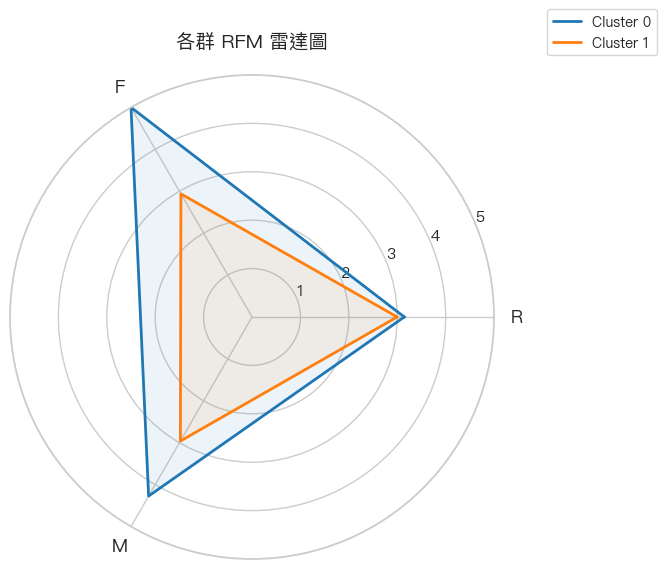

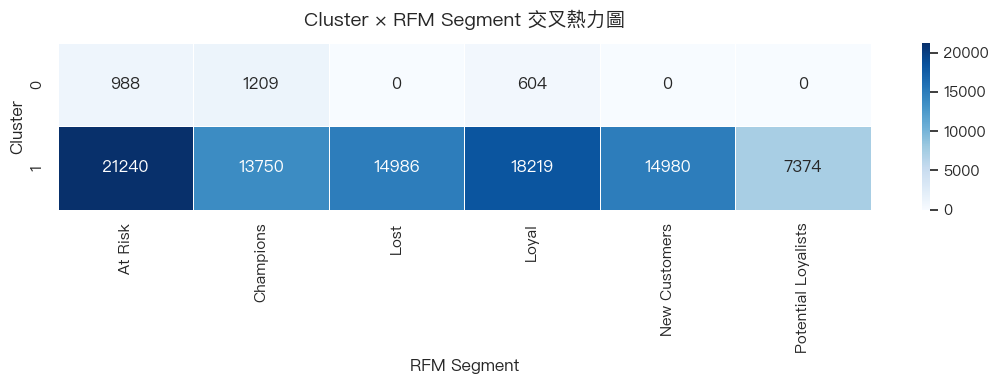

In [68]:
# ── 雷達圖：各群 RFM 側寫 ────────────────────────────────────────
cluster_profile = rfm.groupby('cluster')[['R', 'F', 'M']].mean()
categories = ['R', 'F', 'M']
N      = len(categories)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for idx, row in cluster_profile.iterrows():
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {idx}', color=palette[idx])
    ax.fill(angles, values, alpha=0.08, color=palette[idx])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=13)
ax.set_ylim(0, 5)
ax.set_title("各群 RFM 雷達圖", fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

# ── Cluster × RFM Segment 交叉熱力圖 ────────────────────────────
cross = pd.crosstab(rfm['cluster'], rfm['segment'])

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title("Cluster × RFM Segment 交叉熱力圖", fontsize=14, pad=12)
ax.set_xlabel('RFM Segment')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()